# MX7 phase-first Information³ / pyramid closure

## tl;dr

- The frozen joint four-quadrant sign model did **not** improve all metrics: correlation fell from **0.446** to **0.373**, NRMSE rose from **0.899** to **1.215**, while median angle improved from **56.7°** to **53.1°**.
- The existing MX5 first-moment model remains the best compact model here: correlation **0.596**, NRMSE **0.808**, median angle **48.6°**.
- Conditioning amplitude on all four phase routes reconstructed the particle-first electric target to **3.58e-15** relative L2 error. This is an exact decomposition ceiling, not a forecast.
- The missing structure is therefore not merely the joint sign. It is primarily the dependence between phase route and field magnitude.
- Independent validation reproduces every reported metric exactly and every algebraic identity below `1e-12`.


## Context & Methods

For every particle-to-cell contribution and field component, define charge phase (s_q\in\{-1,+1\}), field phase (s_E\in\{-1,+1\}), relation (r=s_qs_E), magnitude (m=|E|), and absolute-charge activity (Q).

The exact particle-first target is

\[
F^{\rm child}=Q\langle mr\rangle.
\]

The frozen ladder compares

\[
F^{\rm marg}=Q\langle m\rangle\langle s_q\rangle\langle s_E\rangle,
\qquad
F^{\rm joint}=Q\langle m\rangle\langle s_qs_E\rangle,
\]

then the four-route conditioned ceiling

\[
F^{\rm pyramid}=Q\sum_{a,b}p_{ab}\,\bar m_{ab}\,s_as_b
=Q\langle mr\rangle.
\]

The protocol and materiality thresholds were frozen before calculation in `MX7_PHASE_FIRST_INFORMATION3_PYRAMID_PROTOCOL_v1_FROZEN.md`.


In [1]:
from pathlib import Path
import json
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path(r"F:\SystemFormulaFolder\GIT\ARA-GIT\analysis\electromagnetism")
SOURCE = Path(r"F:\SystemFormulaFolder\work_tmp\ara_mx4\legacy_datasets\picongpu-0.5.0-hdf5-plugin\simData_200.h5")
assert SOURCE.exists(), f"Missing public source: {SOURCE}"
print('Python:', sys.executable)
print('Source:', SOURCE)


Python: F:\SystemFormulaFolder\.venv_ara_verify\Scripts\python.exe
Source: F:\SystemFormulaFolder\work_tmp\ara_mx4\legacy_datasets\picongpu-0.5.0-hdf5-plugin\simData_200.h5


## Data

The source is the fixed, hash-checked CC0 openPMD PIConGPU example at iteration 200. It contains electrons, ions and all electromagnetic field components on a 32×32×32 grid. One snapshot supports a closure autopsy, not a temporal or causal claim. The next cell reruns both the analysis and a separate CSV/JSON validator.


In [2]:
commands = [
    [sys.executable, str(HERE / 'mx7_phase_first_information3_pyramid.py'), '--source', str(SOURCE), '--output-dir', str(HERE)],
    [sys.executable, str(HERE / 'mx7_validate_outputs.py'), '--source', str(SOURCE), '--results-dir', str(HERE)],
]
for command in commands:
    completed = subprocess.run(command, check=True, capture_output=True, text=True)
    print(Path(command[1]).name, 'completed')


mx7_phase_first_information3_pyramid.py completed


mx7_validate_outputs.py completed


## Results

In [3]:
results = json.loads((HERE / 'MX7_PHASE_FIRST_INFORMATION3_PYRAMID_RESULTS.json').read_text(encoding='utf-8'))
validation = json.loads((HERE / 'MX7_PHASE_FIRST_INFORMATION3_PYRAMID_VALIDATION.json').read_text(encoding='utf-8'))
print('Frozen classification:', results['joint_phase_result']['classification'])
print('Independent validation:', validation['validation_pass'])
print('Pyramid identity gate:', results['pyramid_identity']['all_identity_errors_le_1e-12'])


Frozen classification: joint quadrant relation did not improve all frozen metrics
Independent validation: True
Pyramid identity gate: True


In [4]:
labels = {
    'flat_parent': 'MX4 flat',
    'mx5_first_moment': 'MX5 first moment',
    'independent_phase_marginals': 'two marginals',
    'joint_quadrant_triangle': 'joint four-route sign',
    'conditioned_amplitude_pyramid': 'conditioned ceiling',
}
pd.DataFrame([
    {
        'model': labels[name],
        'correlation': values['vector_correlation'],
        'NRMSE': values['nrmse_by_target_std'],
        'median angle (deg)': values['median_angular_error_deg'],
        'relative L2': values['relative_l2'],
    }
    for name, values in results['models'].items()
])


,model,correlation,NRMSE,median angle (deg),relative L2
0,MX4 flat,0.467336,8.932518e-01,62.392545,8.931765e-01
1,MX5 first moment,0.596429,8.076845e-01,48.586245,8.076164e-01
2,two marginals,0.445544,8.992902e-01,56.742695,8.992144e-01
3,joint four-route sign,0.372707,1.215068e+00,53.101425,1.214966e+00
4,conditioned ceiling,1.000000,3.576130e-15,0.000000,3.575828e-15


In [5]:
gate = results['joint_phase_result']['frozen_gates']
pd.DataFrame([
    {'quantity': 'correlation relative change', 'value': gate['favourable_relative_changes']['vector_correlation']},
    {'quantity': 'NRMSE favourable relative change', 'value': gate['favourable_relative_changes']['nrmse_by_target_std']},
    {'quantity': 'angle favourable relative change', 'value': gate['favourable_relative_changes']['median_angular_error_deg']},
    {'quantity': 'relative-L2 reduction', 'value': gate['residual_relative_l2_reduction']},
    {'quantity': 'median mutual information (bits)', 'value': results['joint_phase_result']['mutual_information_bits']['p50']},
    {'quantity': 'MI vs |phase correction| Spearman', 'value': results['joint_phase_result']['spearman_mutual_information_vs_abs_phase_correction']},
])


,quantity,value
0,correlation relative change,-0.163479
1,NRMSE favourable relative change,-0.351142
2,angle favourable relative change,0.064172
3,relative-L2 reduction,-0.351142
4,median mutual information (bits),0.000277
5,MI vs |phase correction| Spearman,0.866392


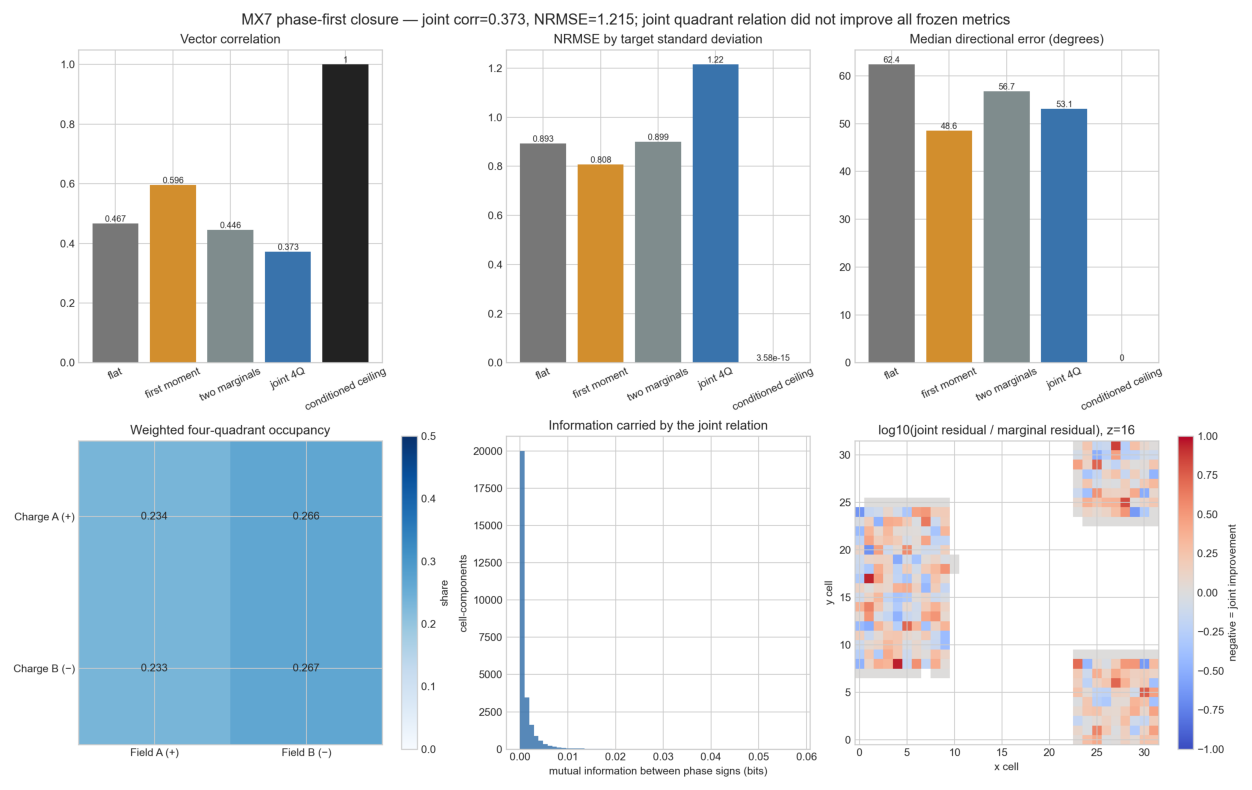

In [6]:
image = plt.imread(HERE / 'MX7_PHASE_FIRST_INFORMATION3_PYRAMID.png')
plt.figure(figsize=(16, 10))
plt.imshow(image)
plt.axis('off')
plt.show()


## Takeaways

1. Preserving the four sign routes is mathematically necessary to avoid a second flattening, but sign occupancy alone is not sufficient on this dataset.
2. The joint sign model slightly improves direction while badly overshooting magnitude; this is why its correlation and NRMSE fail the frozen gate.
3. The exact pyramid closes only after attaching a separate mean magnitude to each route. In plain language, **which route a contribution occupies and how strongly that route is expressed must be kept together**.
4. Mutual information between the two signs is numerically small, yet it strongly locates the absolute phase correction (Spearman 0.866). That makes it a useful diagnostic, not a sufficient predictor.
5. The next honest test is out-of-sample: learn a compact rule for route-conditioned amplitudes on one spatial/time partition and predict a held-out partition. Without that separation, the exact closure is an identity rather than evidence of generalization.
